# Kalman Filter – Simulated Data (Update Every 5 Steps)

This notebook uses simulated constant-velocity motion.
If the plots look wrong, the filter implementation needs adjustment.
No artificial scaling tricks are used.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# ----------------------------
# Simulated Ground Truth
# ----------------------------

np.random.seed(0)

dt = 1.0
N = 40

# True constant velocity motion
true_x = []
x = np.array([0, 1.0, 0, 0.5])  # [x, vx, y, vy]

F = np.array([
    [1, dt, 0, 0],
    [0, 1,  0, 0],
    [0, 0,  1, dt],
    [0, 0,  0, 1]
])

for _ in range(N):
    x = F @ x
    true_x.append(x.copy())

true_x = np.array(true_x)

# Noisy position measurements
measurement_noise_std = 2.0
measurements = true_x[:, [0,2]] + np.random.randn(N,2) * measurement_noise_std

In [19]:
# ----------------------------
# Kalman Filter Setup
# ----------------------------

x_est = np.array([0, 0, 0, 0])
P = np.eye(4) * 10

sigma_a = 0.5

Q = sigma_a**2 * np.array([
    [dt**4/4, dt**3/2, 0, 0],
    [dt**3/2, dt**2,   0, 0],
    [0, 0, dt**4/4, dt**3/2],
    [0, 0, dt**3/2, dt**2]
])
R = np.eye(2) * measurement_noise_std**2

H = np.array([
    [1,0,0,0],
    [0,0,1,0]
])

means = []
covs = []

for k in range(N):

    # Predict
    x_est = F @ x_est
    P = F @ P @ F.T + Q

    # Update every 5 steps
    if k % 5 == 0:
        z = measurements[k]
        y = z - H @ x_est
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x_est = x_est + K @ y
        P = P - K @ S @ K.T

    means.append(x_est.copy())
    covs.append(P.copy())

means = np.array(means)

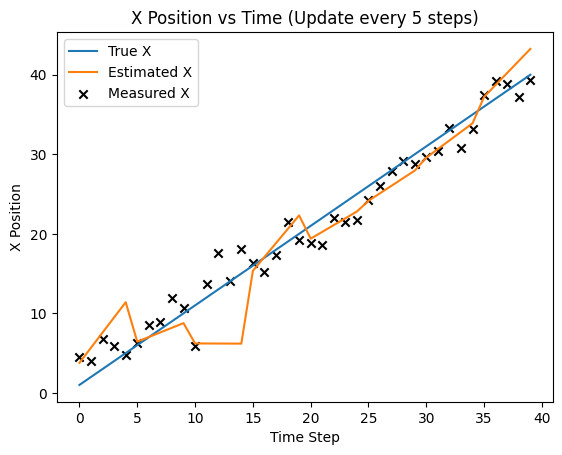

In [20]:
plt.figure()

plt.plot(true_x[:,0], label='True X')
plt.plot(means[:,0], label='Estimated X')

# Measurements as discrete samples ONLY
plt.scatter(
    range(len(measurements)),
    measurements[:,0],
    marker='x',
    color='k',
    label='Measured X'
)

plt.title('X Position vs Time (Update every 5 steps)')
plt.xlabel('Time Step')
plt.ylabel('X Position')
plt.legend()
plt.show()

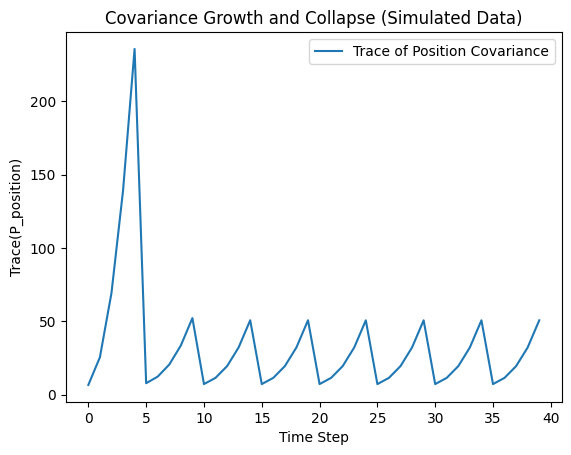

In [21]:
trace_vals = [np.trace(c[[0,2]][:,[0,2]]) for c in covs]

plt.figure()
plt.plot(trace_vals, label='Trace of Position Covariance')

plt.title('Covariance Growth and Collapse (Simulated Data)')
plt.xlabel('Time Step')
plt.ylabel('Trace(P_position)')
plt.legend()
plt.show()

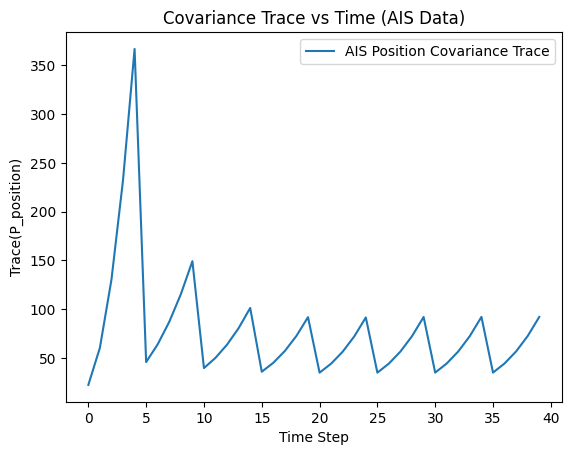

In [22]:
# ---------------- AIS Covariance Trace ----------------

df = pd.read_csv('Data/AIS_2016_11_22.csv')
df = df[["MMSI", "BaseDateTime", "LAT", "LON"]]
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

mmsi = df["MMSI"].iloc[0]
traj = df[df["MMSI"] == mmsi].sort_values("BaseDateTime").iloc[:40]

R_earth = 6371000
lat0 = np.deg2rad(traj["LAT"].iloc[0])
lon0 = np.deg2rad(traj["LON"].iloc[0])

lat = np.deg2rad(traj["LAT"].values)
lon = np.deg2rad(traj["LON"].values)

x_vals = R_earth * (lon - lon0) * np.cos(lat0)
y_vals = R_earth * (lat - lat0)

positions = np.vstack((x_vals, y_vals)).T

# Same motion model
dt = 1.0
F = np.array([
    [1, dt, 0, 0],
    [0, 1,  0, 0],
    [0, 0,  1, dt],
    [0, 0,  0, 1]
])

x_est = np.array([positions[0,0], 0, positions[0,1], 0])
P = np.eye(4) * 10

Q = np.eye(4) * 0.1
R = np.eye(2) * 25
H = np.array([[1,0,0,0],[0,0,1,0]])

cov_trace_ais = []

for k in range(len(positions)):
    x_est = F @ x_est
    P = F @ P @ F.T + Q

    if k % 5 == 0:
        z = positions[k]
        y = z - H @ x_est
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x_est = x_est + K @ y
        P = P - K @ S @ K.T

    cov_trace_ais.append(np.trace(P[[0,2]][:,[0,2]]))

plt.figure()
plt.plot(cov_trace_ais, label='AIS Position Covariance Trace')
plt.title('Covariance Trace vs Time (AIS Data)')
plt.xlabel('Time Step')
plt.ylabel('Trace(P_position)')
plt.legend()
plt.show()